In [1]:
import sys
print(sys.executable)

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df=pd.read_csv('data/train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Ticket"].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [10]:
df["Sex"].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop('Cabin',axis=1,inplace=True)
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')


In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [14]:
df["Sex"]=df["Sex"].map({"male":0,"female":1})
df["Embarked"]=df["Embarked"].map({"S":0,"C":1,"Q":2})

In [ ]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)


In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


# Analysis 1: Survival Count

## Question


What is the overall survival count of passengers on the Titanic?

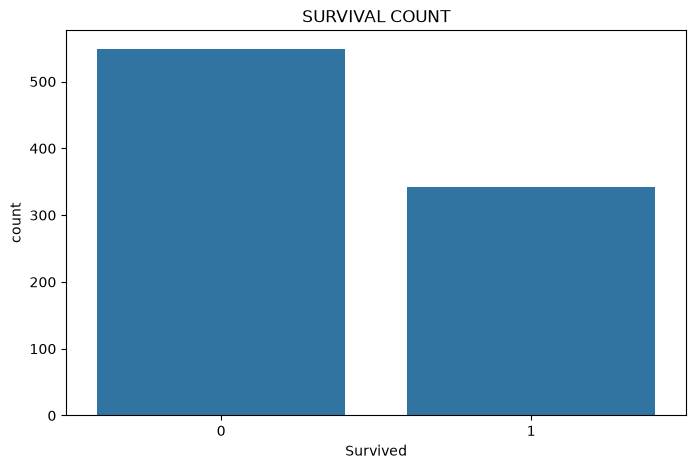

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived',data=df)
plt.title("SURVIVAL COUNT")
plt.savefig("images/survival_count.png", dpi=300, bbox_inches="tight")
plt.show()


## Observation

The graph shows that more passengers did not survive than survived.

## Conclusion

The majority of passengers on the Titanic did not survive the disaster.

# Analysis 2: Survival by Gender

## Question

Which gender had a higher survival rate?

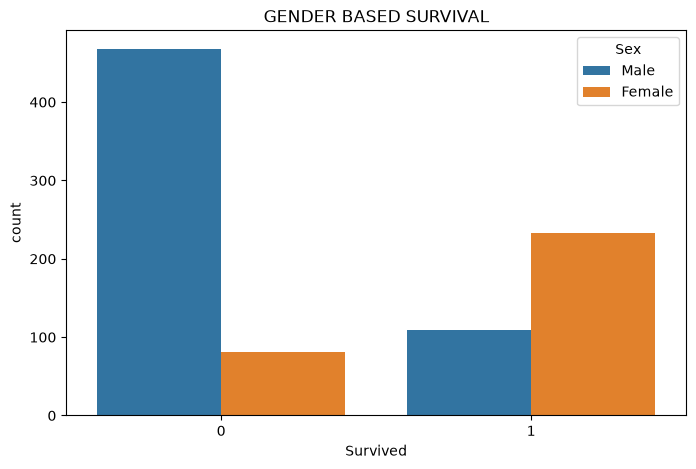

In [21]:
plot_df = df.copy()

plot_df["Sex"] = plot_df["Sex"].map({
    0: "Male",
    1: "Female"
})
plt.figure(figsize=(8,5))
sns.countplot(x="Survived",hue="Sex",data=plot_df)
plt.title("GENDER BASED SURVIVAL")
plt.savefig("images/gender_survival.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

The graph shows that female passengers had a higher survival rate than male passengers. Most of the passengers who did not survive were male.

## Conclusion

Gender appears to have been an important factor influencing passenger survival during the Titanic disaster.

# Analysis 3: Survival by Passenger Class

## Question

Which passenger class had the highest survival rate?

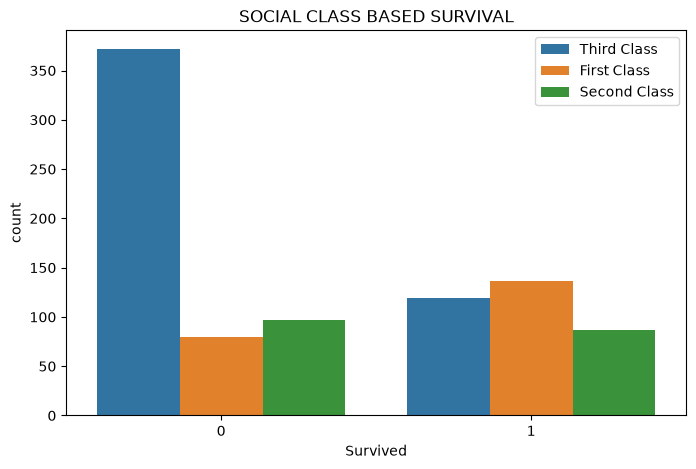

In [22]:
plot_df = df.copy()

plot_df["Pclass"] = plot_df["Pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})
plt.figure(figsize=(8,5))
sns.countplot(x="Survived",hue="Pclass",data=plot_df)
plt.title("SOCIAL CLASS BASED SURVIVAL")
plt.legend()
plt.savefig("images/class_survival.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

The graph shows that third-class passengers had the highest number of deaths. In contrast, first-class passengers had the highest number of survivors, while second-class passengers had a moderate number of both survivors and non-survivors.

## Conclusion

Passenger class had a significant impact on survival. First-class passengers were more likely to survive, whereas third-class passengers were the least likely to survive during the Titanic disaster.


# Analysis 4: Age Distribution

## Question

What was the age distribution of the passengers?

<Axes: xlabel='Age', ylabel='Count'>

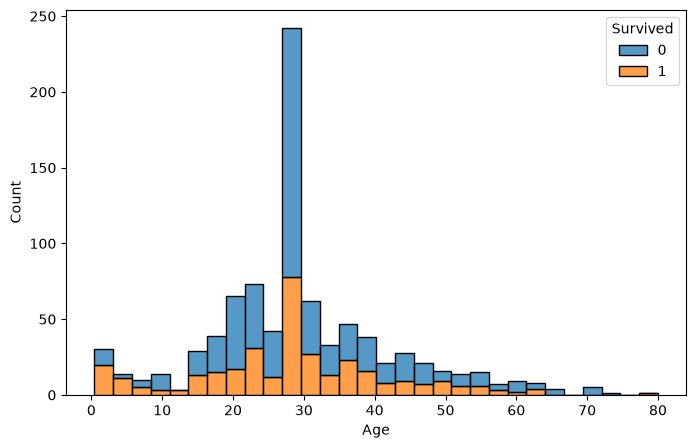

In [23]:

plt.figure(figsize=(8,5))
plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")
sns.histplot(data=df,x="Age", hue="Survived",bins=30,multiple="stack")

## Observation

The graph shows that most passengers were between 20 and 35 years of age. There were fewer children and elderly passengers. Both survivors and non-survivors were primarily from the 20–35 age group.


## Conclusion

The majority of Titanic passengers were young adults. Although passengers of all ages were affected, the largest number of both survivors and non-survivors belonged to the 20–35 age group.

# Analysis 5: Fare Distribution

## Question

How were ticket fares distributed among passengers?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38928\330085746.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


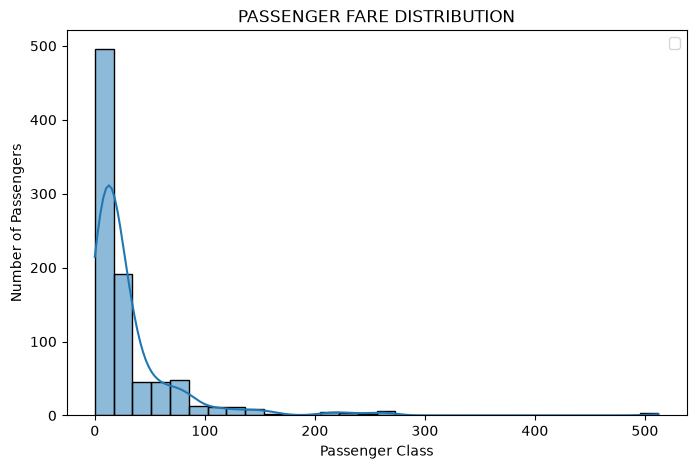

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30,kde=True)
plt.title("PASSENGER FARE DISTRIBUTION")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend()
plt.savefig("images/fare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## Observation

The graph shows that most passengers paid relatively low fares, while only a few passengers paid very high fares. The fare distribution is positively skewed.

## Conclusion

Most Titanic passengers traveled with low-priced tickets, whereas only a small number of passengers purchased expensive tickets.

# Analysis 6: Survival by Age

## Question

Did age have an impact on passenger survival?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38928\41334685.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


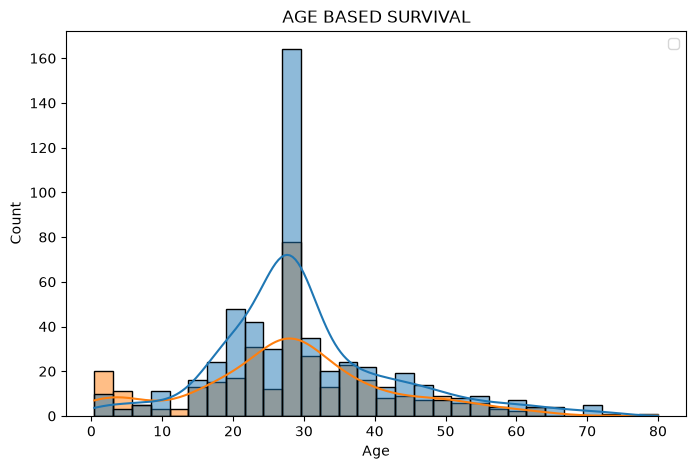

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Age",hue="Survived", bins=30,kde=True)
plt.title("AGE BASED SURVIVAL")
plt.legend()
plt.savefig("images/age_survival.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

The histogram shows that most passengers were between 20 and 35 years of age. Both survivors and non-survivors were concentrated in this age group. Very few passengers were older than 60 years, and only a small number of young children were present on the Titanic.

## Conclusion

The majority of Titanic passengers belonged to the 20–35 age group. Although passengers from all age groups were affected, age alone did not determine survival. Other factors such as gender, passenger class, and ticket fare appeared to have a greater influence on survival.

# Analysis 7:  Survival by Fare

## Question

Did passengers who paid higher fares have better survival rates?

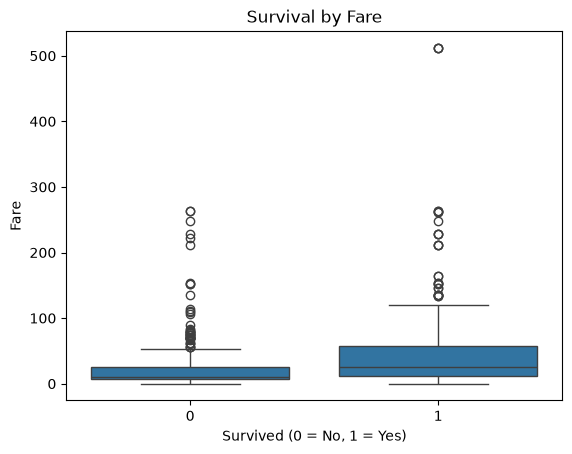

In [29]:
sns.boxplot(x="Survived", y="Fare", data=df)

plt.title("Survival by Fare")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.savefig("images/survival_by_fare.png", dpi=300, bbox_inches="tight")

plt.show()

## Observation

The box plot shows that passengers who survived generally paid higher ticket fares than those who did not survive. The median fare is higher for survivors, and several survivors paid exceptionally high fares.

## Conclusion

Passengers who paid higher ticket fares had a greater chance of surviving the Titanic disaster. This suggests that ticket fare, which is closely related to passenger class, was an important factor influencing survival.

# Analysis 8: Correlation Analysis

## Question

Which features were most strongly associated with passenger survival?

Survived    1.000000
Sex         0.543351
Fare        0.257307
Embarked    0.106811
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Pclass     -0.338481
Name: Survived, dtype: float64


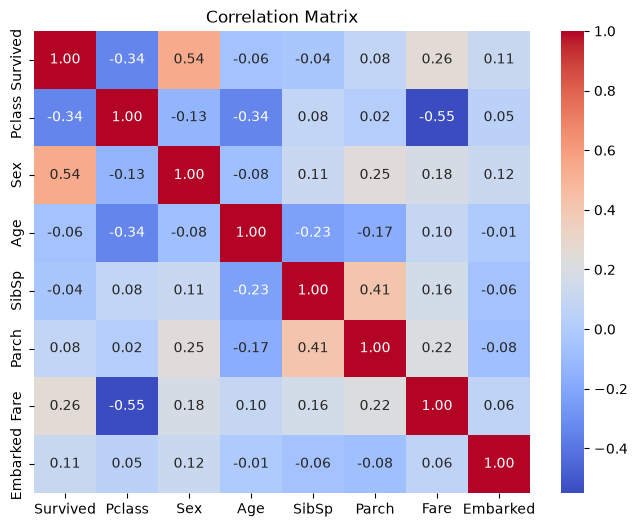

In [30]:
corr = df.corr(numeric_only=True)
print(corr["Survived"].sort_values(ascending=False))
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("images/correlation_matrix.png", dpi=300, bbox_inches="tight")  
plt.show()


## Observation
- **Sex**, **Pclass**, and **Fare** showed the strongest correlation with survival.
- Other features had weak correlations.

## Conclusion
- **Sex**, **Pclass**, and **Fare** were the most important factors affecting passenger survival.

# Final Insights

- More passengers did not survive than survived.
- Female passengers had a higher survival rate than male passengers.
- First-class passengers were more likely to survive than second- and third-class passengers.
- Most passengers were between 20 and 35 years of age.
- Most passengers paid relatively low ticket fares.
- Passengers who paid higher fares generally had better survival rates.
- Passenger class, gender, and fare were the strongest factors associated with survival.

## Conclusion

This exploratory data analysis (EDA) of the Titanic dataset shows that gender, passenger class, and ticket fare had the greatest influence on survival. The project demonstrates the use of Python, Pandas, Matplotlib, and Seaborn for data cleaning, visualization, and extracting meaningful insights from real-world data.